# Portfolio Risk & Performance Review

**Purpose.** The PM-facing review of a strategy that has already passed research
(`research.ipynb`) and out-of-sample validation (`walk_forward.ipynb`) and optimization (`walk_forward_optimization.ipynb`). This notebook assumes the signal and parameters 
are already decided, and asks the questions a risk committee actually asks before 
allocating capital: what's the worst historical drawdown and how long did it take 
to recover, where does the risk actually come from, is the sizing pipeline respecting 
its own limits, and how does this compare across the allocator choices available.

## 0. Setup

In [1]:
import sys
from pathlib import Path

# Make sure the project root (where config.py lives) is importable, no
# matter which directory Jupyter was launched from. Fixes the classic
# "ModuleNotFoundError: No module named 'config'" when the kernel's
# working directory isn't the project root.

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "config.py").exists() and (PROJECT_ROOT.parent / "config.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/davidyekara/Downloads/Algorithmic Trading Cookbook/VectorBT/Technical Strategies


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import config
import database
from strategy_engine import get_strategy, STRATEGY_REGISTRY, ma_crossover_grid
from signal_generator import SignalGenerator, signals_to_position_state
import portfolio_engine
from backtester import run_backtest, run_buy_and_hold, run_parameter_sweep
from performance_analytics import (
    summary_stats, 
    portfolio_level_stats, 
    compare_to_benchmark, 
    portfolio_equity,
    )
from feature_engine import FeatureEngine

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (13, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

ALLOCATORS = {
    "equal_weight": (portfolio_engine.equal_weight, {}),
    "volatility_weight": (portfolio_engine.volatility_weight, None),   # needs returns, filled in below
    "risk_parity": (portfolio_engine.risk_parity, None),
    "kelly_weight": (portfolio_engine.kelly_weight, None),
}

In [3]:
database.init_db()
prices = database.load_bars(config.UNIVERSE)
assert not prices.empty, "No data in DB yet -- run `python main.py refresh` first."

log_returns = np.log(prices / prices.shift(1))
for name, (fn, kwargs) in ALLOCATORS.items():
    if kwargs is None:
        ALLOCATORS[name] = (fn, {"returns": log_returns})

print(f"Universe: {list(prices.columns)}")
print(f"Date range: {prices.index.min().date()} -> {prices.index.max().date()}  ({len(prices)} bars)")
prices.tail()

Universe: ['AAPL', 'AMZN', 'MSFT', 'NVDA', 'GOOG']
Date range: 2018-07-24 -> 2026-08-17  (2027 bars)


symbol,AAPL,AMZN,MSFT,NVDA,GOOG
datetime,,,,,
2026-08-11,304.9100,272.2700,503.8100,217.5000,343.0000
2026-08-12,302.2500,267.2800,492.4300,224.0900,342.3700
2026-08-13,305.2600,265.1300,496.8800,225.3000,343.9400
2026-08-14,305.9300,262.6500,495.4000,225.1600,343.5400
2026-08-17,305.5900,261.3100,480.3500,225.0100,341.4500


In [4]:
CHOSEN_ALLOCATOR = "equal_weight"   # the allocator being proposed for capital
strategy = get_strategy(config.DEFAULT_STRATEGY.name)
sig_gen = SignalGenerator(strategy)
entries, exits = sig_gen.full_history_signals(prices)

allocator, allocator_kwargs = ALLOCATORS[CHOSEN_ALLOCATOR]
pf = run_backtest(prices, entries, exits, allocator=allocator, allocator_kwargs=allocator_kwargs)
pf_hold = run_buy_and_hold(prices)

equity, daily_returns = portfolio_equity(
    pf,
    prices
)
benchmark_equity, benchmark_returns = portfolio_equity(
    pf_hold,
    prices
)

## 1. Headline tearsheet

The numbers that go in the first slide of a strategy proposal.

In [5]:
def annualized_return(r): return (1 + r).prod() ** (252 / len(r)) - 1
def annualized_vol(r): return r.std() * np.sqrt(252)
def sharpe(r): return r.mean() / r.std() * np.sqrt(252) if r.std() > 0 else np.nan
def sortino(r):
    downside = r[r < 0]
    dd = downside.std() * np.sqrt(252) if len(downside) else np.nan
    return annualized_return(r) / dd if dd else np.nan
def max_drawdown(equity_curve):
    dd = (equity_curve - equity_curve.cummax()) / equity_curve.cummax()
    return dd.min()
def calmar(r, equity_curve): return annualized_return(r) / abs(max_drawdown(equity_curve))

headline = pd.Series({
    "Total return": (equity.iloc[-1] / equity.iloc[0] - 1),
    "CAGR": annualized_return(daily_returns),
    "Annualized volatility": annualized_vol(daily_returns),
    "Sharpe": sharpe(daily_returns),
    "Sortino": sortino(daily_returns),
    "Max drawdown": max_drawdown(equity),
    "Calmar": calmar(daily_returns, equity),
    "Benchmark (buy&hold) total return": (benchmark_equity.iloc[-1] / benchmark_equity.iloc[0] - 1),
})
headline.to_frame("value").style.format("{:.4f}")

,value
Total return,3.2363
CAGR,0.1966
Annualized volatility,0.2050
Sharpe,0.9785
Sortino,1.0713
Max drawdown,-0.2637
Calmar,0.7456
Benchmark (buy&hold) total return,10.4701


In [6]:
equity, daily_returns = portfolio_equity(pf, prices)

total_return = equity.iloc[-1] / equity.iloc[0] - 1

print(f"Equity start:       ${equity.iloc[0]:,.2f}")
print(f"Equity end:         ${equity.iloc[-1]:,.2f}")
print(f"Mean daily return:  {daily_returns.mean():.4%}")
print(f"Std daily return:   {daily_returns.std():.4%}")
print(f"Total return:       {total_return:.2%}")


Equity start:       $100,000.00
Equity end:         $423,629.58
Mean daily return:  0.0796%
Std daily return:   1.2912%
Total return:       323.63%


## 2. Equity curve & underwater drawdown chart

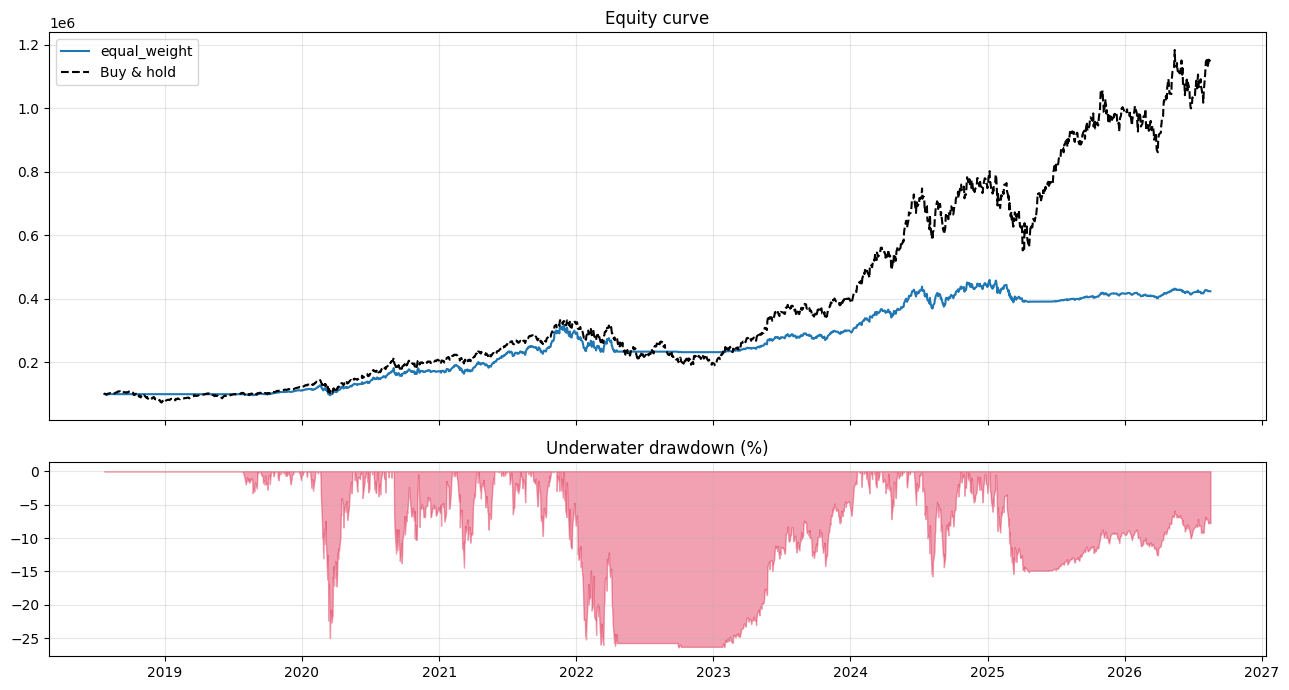

In [7]:
running_max = equity.cummax()
drawdown = (equity - running_max) / running_max

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
axes[0].plot(equity.index, equity, label=CHOSEN_ALLOCATOR)
axes[0].plot(benchmark_equity.index, benchmark_equity, label="Buy & hold", color="black", linestyle="--")
axes[0].set_title("Equity curve")
axes[0].legend()
axes[1].fill_between(drawdown.index, drawdown * 100, 0, color="crimson", alpha=0.4)
axes[1].set_title("Underwater drawdown (%)")
plt.tight_layout()
plt.show()

## 3. Rolling risk metrics

Point-in-time Sharpe hides regime changes -- a strategy that was great for 3
years and terrible for 1 can still show an acceptable full-period Sharpe.

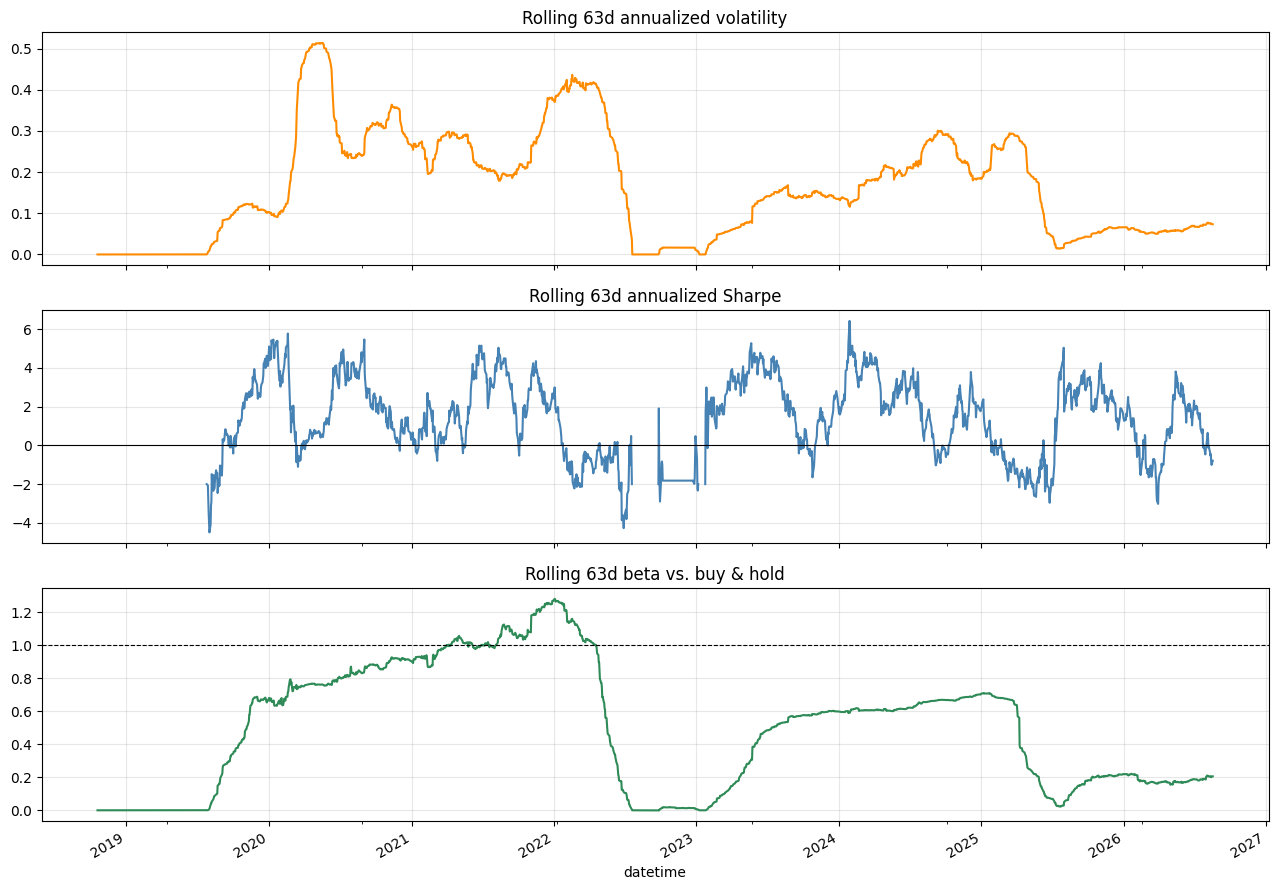

In [8]:
window = 63
rolling_vol = daily_returns.rolling(window).std() * np.sqrt(252)
rolling_sharpe = (daily_returns.rolling(window).mean() / daily_returns.rolling(window).std()) * np.sqrt(252)
aligned_bench = benchmark_returns.reindex(daily_returns.index)
rolling_cov = daily_returns.rolling(window).cov(aligned_bench)
rolling_var = aligned_bench.rolling(window).var()
rolling_beta = rolling_cov / rolling_var

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
rolling_vol.plot(ax=axes[0], color="darkorange"); axes[0].set_title(f"Rolling {window}d annualized volatility")
rolling_sharpe.plot(ax=axes[1], color="steelblue"); axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title(f"Rolling {window}d annualized Sharpe")
rolling_beta.plot(ax=axes[2], color="seagreen"); axes[2].axhline(1, color="black", linewidth=0.8, linestyle="--")
axes[2].set_title(f"Rolling {window}d beta vs. buy & hold")
plt.tight_layout()
plt.show()

## 4. Return distribution & tail risk

Historical (non-parametric) VaR/CVaR from the realized daily return distribution
-- a quick, assumption-light gut check on tail risk, not a substitute for a
proper risk model.

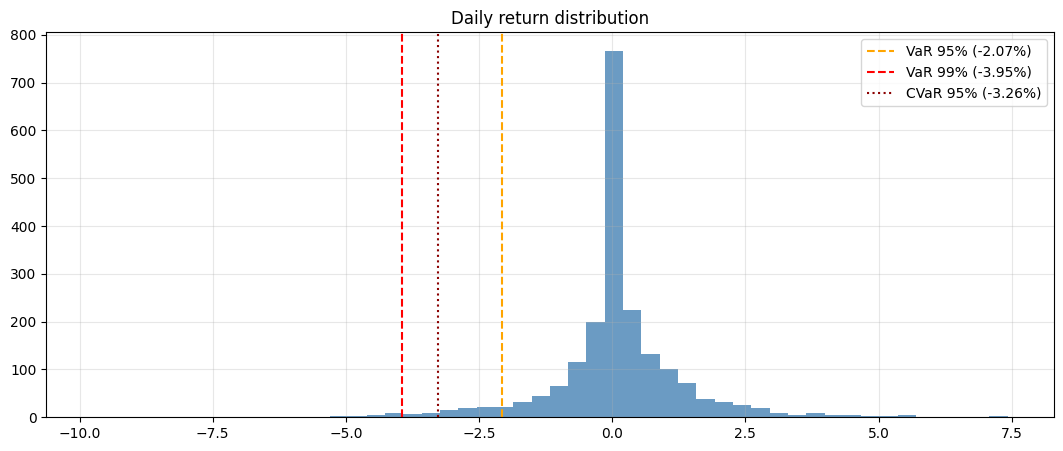

Skew: -0.16   Kurtosis: 7.28


In [9]:
var_95 = np.percentile(daily_returns, 5)
var_99 = np.percentile(daily_returns, 1)
cvar_95 = daily_returns[daily_returns <= var_95].mean()

fig, ax = plt.subplots()
ax.hist(daily_returns * 100, bins=50, color="steelblue", alpha=0.8)
ax.axvline(var_95 * 100, color="orange", linestyle="--", label=f"VaR 95% ({var_95*100:.2f}%)")
ax.axvline(var_99 * 100, color="red", linestyle="--", label=f"VaR 99% ({var_99*100:.2f}%)")
ax.axvline(cvar_95 * 100, color="darkred", linestyle=":", label=f"CVaR 95% ({cvar_95*100:.2f}%)")
ax.set_title("Daily return distribution")
ax.legend()
plt.show()

print(f"Skew: {daily_returns.skew():.2f}   Kurtosis: {daily_returns.kurtosis():.2f}")

## 5. Return & risk contribution by symbol

Which names are actually driving the number in section 1 -- a strategy that looks
diversified in its symbol list but gets all its return (or all its risk) from one
name is a concentrated bet wearing a diversified costume.

In [ ]:
symbol_returns = pf.returns()
symbol_total_return = pf.total_return()
symbol_vol = symbol_returns.std() * np.sqrt(252)

if isinstance(symbol_total_return.index, pd.MultiIndex):
    symbol_total_return.index = symbol_total_return.index.get_level_values(-1)
    symbol_returns.columns = symbol_returns.columns.get_level_values(-1)

if isinstance(symbol_vol.index, pd.MultiIndex):
    symbol_vol.index = symbol_vol.index.get_level_values(-1)

contribution = pd.DataFrame({
    "total_return": symbol_total_return,
    "annualized_vol": symbol_vol,
    "return_contribution_pct": (symbol_total_return / symbol_total_return.sum() * 100).round(1),
})
contribution

,total_return,annualized_vol,return_contribution_pct
symbol,,,
AAPL,0.0357,0.0335,1.1000
AMZN,0.1823,0.0628,5.6000
MSFT,0.1114,0.0334,3.4000
NVDA,2.4193,0.1818,74.8000
GOOG,0.4875,0.0705,15.1000


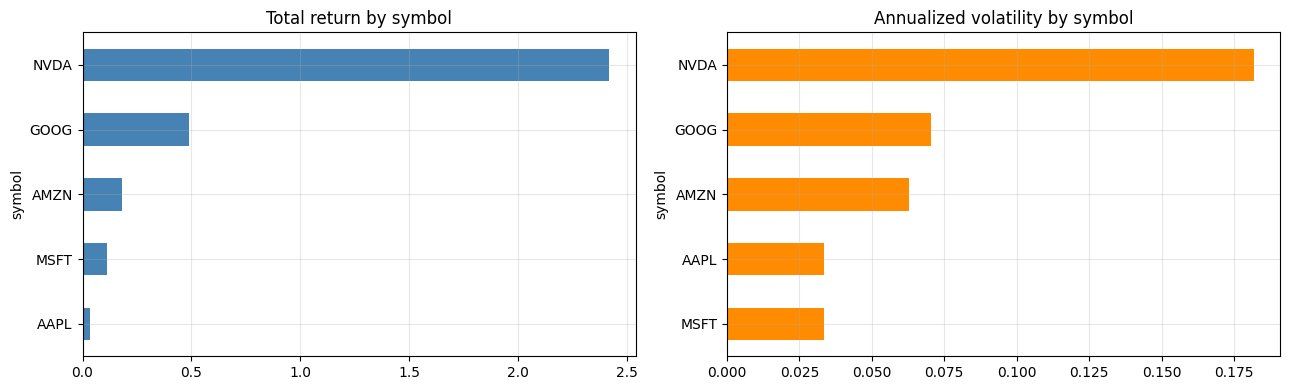

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
contribution["total_return"].sort_values().plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("Total return by symbol")
contribution["annualized_vol"].sort_values().plot.barh(ax=axes[1], color="darkorange")
axes[1].set_title("Annualized volatility by symbol")
plt.tight_layout()
plt.show()

## 6. Exposure over time (risk-limit compliance)

Gross exposure should never cross `config.RISK.max_gross_exposure` (red line) --
if it does, this is a sizing-pipeline bug, not a market outcome, and needs fixing
before this strategy goes anywhere near real capital.

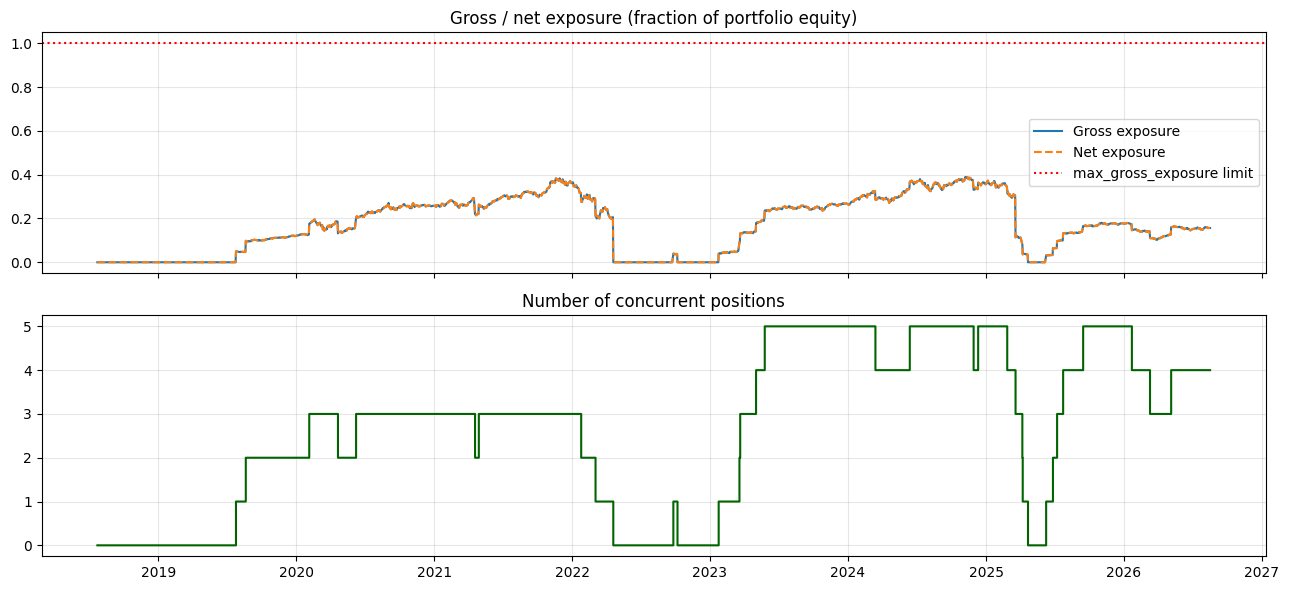

Risk-limit compliance check: PASS


In [ ]:
shares = pf.assets()

if isinstance(shares.columns, pd.MultiIndex):
    shares.columns = shares.columns.get_level_values(-1)

aligned_prices = prices.reindex(index=shares.index, columns=shares.columns)
position_values = shares.abs() * aligned_prices
gross_position_value = position_values.sum(axis=1)

net_position_value = (
    shares * aligned_prices
).sum(axis=1)

portfolio_curve = pf.value().sum(axis=1)
gross_exposure = gross_position_value / portfolio_curve
net_exposure = net_position_value / portfolio_curve
n_positions = (shares.abs() > 0).sum(axis=1)

fig, axes = plt.subplots(
    2, 1,
    figsize=(13, 6),
    sharex=True
)

axes[0].plot(gross_exposure.index, gross_exposure, label="Gross exposure")
axes[0].plot(
    net_exposure.index,
    net_exposure,
    linestyle="--",
    label="Net exposure"
)
axes[0].axhline(config.RISK.max_gross_exposure, color="red", linestyle=":", label="max_gross_exposure limit")
axes[0].set_title("Gross / net exposure (fraction of portfolio equity)")
axes[0].legend()
axes[1].plot(
    n_positions.index,
    n_positions,
    drawstyle="steps-post",
    color="darkgreen"
)
axes[1].set_title("Number of concurrent positions")

plt.tight_layout()
plt.show()

breaches = (
    gross_exposure
    > config.RISK.max_gross_exposure + 1e-6
).sum()

status = ("PASS" if breaches == 0 else f"FAIL -- {breaches} bars over limit"
)

print(f"Risk-limit compliance check: {status}"
)

## 7. Correlation matrix

High pairwise correlation across "different" symbols means the portfolio has less
effective diversification than the symbol count suggests.

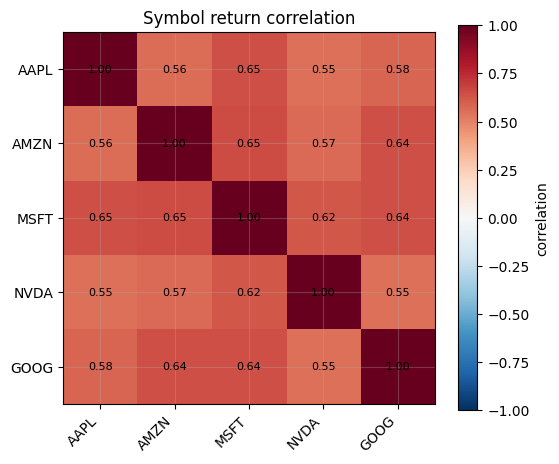

In [13]:
corr = log_returns.corr()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.values[i,j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="correlation")
ax.set_title("Symbol return correlation")
plt.show()

## 8. Drawdown table

The largest historical peak-to-trough moves, with recovery time -- the "how bad
could a quarter get" table.

In [ ]:
dd_records = pf.drawdowns.records_readable
if len(dd_records):
    dd_records = dd_records.copy()
    dd_records["Symbol"] = dd_records["Column"].apply(lambda x: x[0] if isinstance(x, tuple) else x)
    dd_records["Drawdown %"] = (dd_records["Valley Value"] / dd_records["Peak Value"] - 1) * 100
    top_dd = dd_records.sort_values("Drawdown %").head(5)
    display(top_dd[["Symbol", "Peak Timestamp", "Valley Timestamp", "End Timestamp",
                     "Drawdown %", "Status"]])
else:
    print("No completed drawdown records available for this portfolio.")

,Symbol,Peak Timestamp,Valley Timestamp,End Timestamp,Drawdown %,Status
137,NVDA,2021-11-29,2022-04-14,2024-02-14,-26.3354,Recovered
150,NVDA,2025-01-06,2025-03-10,2026-08-17,-14.8366,Active
106,NVDA,2020-02-19,2020-03-16,2020-05-11,-14.2858,Recovered
146,NVDA,2024-06-18,2024-08-07,2024-10-14,-13.4663,Recovered
120,NVDA,2021-02-16,2021-03-08,2021-04-13,-13.3262,Recovered


## 9. Allocator scorecard

Side-by-side comparison across every available PortfolioAllocator, for the risk
committee to see what was actually considered before this one was proposed.

Note: max_position_pct is an entry-time sizing cap, not a continuous mark-to-market
exposure cap. Positions can drift above the 25% cap as prices move after entry. 
Therefore, the allocator comparison below also reports average position weights, 
which helps explain why different allocators can produce very similar portfolio-level performance.

In [ ]:
allocator_weights = {}

for name, (alloc_fn, alloc_kwargs) in ALLOCATORS.items():

    alt_pf = run_backtest(
        prices,
        entries,
        exits,
        allocator=alloc_fn,
        allocator_kwargs=alloc_kwargs
    )

    shares = alt_pf.assets()

    if isinstance(shares.columns, pd.MultiIndex):
        shares.columns = shares.columns.get_level_values(-1)

    weights = (shares.abs().div(shares.abs().sum(axis=1), axis=0).mean())
    allocator_weights[name] = weights

allocator_weights_df = pd.DataFrame(allocator_weights).T
allocator_weights_df


symbol,AAPL,AMZN,MSFT,NVDA,GOOG
equal_weight,0.0533,0.0784,0.0335,0.7121,0.1227
volatility_weight,0.0519,0.0774,0.0338,0.7148,0.1221
risk_parity,0.0545,0.0778,0.0342,0.7191,0.1144
kelly_weight,0.0525,0.2686,0.0375,0.3336,0.3078


In [16]:
scorecard = {}
for name, (alloc_fn, alloc_kwargs) in ALLOCATORS.items():
    alt_pf = run_backtest(prices, entries, exits, allocator=alloc_fn, allocator_kwargs=alloc_kwargs)
    alt_equity, alt_returns = portfolio_equity(
    alt_pf,
    prices
    )
    scorecard[name] = {
        "CAGR": annualized_return(alt_returns),
        "Sharpe": sharpe(alt_returns),
        "Max drawdown": max_drawdown(alt_equity),
        "Calmar": calmar(alt_returns, alt_equity),
    }
scorecard_df = pd.DataFrame(scorecard).T
scorecard_df["proposed"] = scorecard_df.index == CHOSEN_ALLOCATOR
scorecard_df

,CAGR,Sharpe,Max drawdown,Calmar,proposed
equal_weight,0.1966,0.9785,-0.2637,0.7456,True
volatility_weight,0.1964,0.9787,-0.2637,0.7449,False
risk_parity,0.1951,0.9742,-0.2637,0.7398,False
kelly_weight,0.1499,0.9145,-0.2141,0.7004,False


## 10. Sign-off checklist

A simple template -- fill in before this goes to a risk committee. This is
deliberately not automated: a human should be answering each line, not a script.

| Check | Answer | Notes |
|---|---|---|
| Out-of-sample validated (see `walk_forward.ipynb` and `walk_forward_optimization.ipynb` )? | | |
| Max drawdown within mandate tolerance? | | |
| Sharpe exceeds the fund's hurdle rate? | | |
| Gross exposure limit respected at all times (section 6)? | | |
| No single name drives an outsized share of return/risk (section 5)? | | |
| Correlation structure understood and acceptable (section 7)? | | |
| Allocator choice justified vs. alternatives (section 9)? | | |
| Capacity / liquidity considered for the intended size? | | |
| Live execution plan (IBKR dry-run track record) reviewed? | | |